<a href="https://colab.research.google.com/github/victorino92/Detec_Lavagem_de_Dinheiro_com_ML_v2/blob/main/Detec%C3%A7%C3%A3o_de_Lavagem_de_Dinheiro_com_ML_v2_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detecção de Lavagem de Dinheiro com ML — v2.0

> **Versão refeita com rigor estatístico após análise crítica externa identificar erros estruturais na v1.**

---

## Sobre este notebook

Este é um **projeto pessoal de portfólio** focado em aprender e demonstrar fundamentos de Ciência de Dados aplicados a detecção de fraude financeira (AML — Anti Money Laundering).

A **v1** deste projeto foi um exercício didático feito em um módulo da pós graduação em Ciência de Dados pela IPOG que aplicou CRISP-DM, feature engineering em grafo de transações, e comparou 4 modelos (Isolation Forest, Logistic Regression, Random Forest, XGBoost) no dataset IBM AML HI-Small.

Após a v1 ser submetida a uma análise crítica formal, **5 erros estruturais foram identificados** — alguns críticos. Esta **v2** reconstrói o pipeline corrigindo cada erro, **explicando o que estava errado, por que estava errado, e como corrigir**.

> ###  Por que isto importa
>
> Este notebook mostra o **processo de descoberta de erros e correção rigorosa**.
>
> O foco aqui é aprendizado: identificar erros estatísticos sutis, entender por que ocorrem, e corrigi-los com rigor. Todo o código é executável e reproduzível.

## 🎯 TL;DR — Resultados

**A v1 reportou PR-AUC de 0.2418 para o XGBoost.** Após correção estatística rigorosa, o resultado verdadeiro é **menor mas estatisticamente válido**, e a metodologia agora é defensável em qualquer auditoria técnica.

O valor pedagógico está na **trajetória da correção**, não no número final.

---

##  Os erros Estruturais da v1

Antes de qualquer código, é fundamental entender o que estava errado. Cada erro abaixo será atacado em uma seção específica deste notebook.


## Erro #1 — Armadilha Combinatória do Rótulo (Multinomial Trap)

**O que foi feito na v1:**

Definimos o rótulo de uma conta como:
$$\text{touched\_fraud}(c) = \max\{\text{is\_laundering}(t) : t \in \text{Transações}(c)\}$$

Em resumo: "conta tocou fraude se **pelo menos uma** de suas transações é fraudulenta".

**Por que está errado:**

Sob hipótese de fraude aleatória uniforme com probabilidade $p \approx 0.001$ por transação, a probabilidade de uma conta "tocar fraude" depende **mecanicamente** do número de transações:

$$P(\text{touched\_fraud}=1 \mid n) = 1 - (1-p)^n$$

| Número de transações ($n$) | Probabilidade de "tocar fraude" por sorteio |
|---|---|
| 1 | 0.10% |
| 10 | 1.00% |
| 100 | 9.5% |
| 1.000 | 63% |
| 10.000 | 99.996% |

Uma conta com 1.000 transações tem **630× mais chance** de "tocar fraude" do que uma com 1 transação, **mesmo sem nenhum comportamento ilícito**.

**Consequência prática:**

Como `total_unique_partners` (a feature dominante no nosso XGBoost com 43% de importância) é fortemente correlacionada com `n_total`, e `n_total` é proxy mecânico do rótulo, **o modelo pode estar aprendendo apenas "conta com muitas transações → fraude" — uma tautologia, não um insight**.

**Diagnóstico feito:**

```
PR-AUC baseline trivial f(c) = n_total: 0.0240
PR-AUC XGBoost (v1): 0.2418
Lift real do XGBoost sobre baseline volume: 10.06×
```

**Conclusão:** o efeito existe, mas é controlado. XGBoost aprende padrões reais além de volume (lift de 10× é substancial). Porém, **o teste deveria ter sido feito antes** de qualquer comparação de modelos — disciplina ausente na v1.

**Como corrigir na v2:**

Mudamos a definição de rótulo para `y_c = (n_fraude_c / n_total_c) > 0.05`. Uma conta agora é rotulada como fraudulenta apenas se **pelo menos 5% das suas transações** forem fraude. Essa normalização **quebra a inflação combinatória**.

---

### Erro #2 — Vazamento Topológico de Features

**O que fiz na v1:**

```python
# Sequência v1 (ERRADA):
features = compute_topology(df_completo)   # Calcula sobre TUDO
X_train, X_test = split(features)          # Depois separa
```

**Por que está errado:**

Features como `out_degree`, `partner_max_n_total`, `reciprocal_count` foram calculadas sobre o **grafo inteiro de transações**, antes de fazer o split treino/teste.

Isso significa que:
- O `out_degree` de uma conta de **teste** foi calculado contando arestas que conectam essa conta a outras contas que estão no **treino**.
- O `partner_max_n_total` de uma conta de teste usa o `n_total` de seus parceiros — incluindo parceiros que estão no treino.
Formalmente: existe um **anel de dependência informacional** entre treino e teste:

$$I(X_{\text{test}}; Y_{\text{train}}) > 0$$

Isso **viola o pressuposto IID** (independente e identicamente distribuído) que sustenta toda a inferência de generalização do modelo. Em termos práticos: **o modelo já viu informação sobre o teste durante o treino**, e nossa PR-AUC reportada está inflada por uma quantidade desconhecida.

**Magnitude do problema:**

Não soube dizer. Pode estar inflando o PR-AUC em 5%, 15% ou 30%. Esta é uma das coisas que a v2 vai descobrir.

**Como corrigimos na v2:**

Reorganizamos o pipeline:

```python
# Sequência v2 (CORRETA):
df_train, df_test = split(df_completo, by="conta")    # Separa PRIMEIRO
features_train = compute_features(df_train)           # Treino: só dados de treino
features_test = compute_features_test(df_test, df_train)  # Teste: contexto histórico permitido
```

A diferença sutil: features de teste **podem** usar contexto histórico do treino (realístico em produção, onde você vê o grafo histórico), mas features de treino **não podem** ver nada do teste (anti-vazamento).

---

### Erro #3 — Interpretação Incorreta do Jaccard

**O que fiz na v1:**

Calculei a similaridade Jaccard entre o top-1% do RF e do XGBoost. Resultado: ~0.35. Concluímos:

> "Modelos da mesma família concordam em apenas 35% — fraude é heterogênea, ensemble justificado."

**Por que está errado:**

Top-1% = 1.545 contas, com precision ≈ 28%. Isso significa **~433 True Positives e ~1.112 False Positives por modelo**. Quando calculei Jaccard sobre o conjunto inteiro do top-1%, a similaridade é **dominada pela concordância em False Positives**, não pela concordância em fraudes reais.

Decomposição:

$$J(A, B) = \frac{|TP_A \cap TP_B| + |FP_A \cap FP_B|}{|TP_A \cup TP_B| + |FP_A \cup FP_B|}$$

Mesmo se os dois modelos concordarem em **90% dos TPs** (sinal de fraude **homogênea**), Jaccard global pode dar 0.35 porque os FPs divergem muito.

**A análise correta:**

Para inferir heterogeneidade real, precisamos calcular Jaccard **apenas entre os TPs**:

$$J_{TP}(A, B) = \frac{|TP_A \cap TP_B|}{|TP_A \cup TP_B|}$$

- Se $J_{TP} \approx 0.9$ → fraude é **homogênea** (modelos veem o mesmo padrão)
- Se $J_{TP} \approx 0.4$ → fraude é **heterogênea** (tipologias distintas)
**Como corrigimos na v2:** recalculei o Jaccard restrito a TPs.

---

### Erro #4 — Comparação Cross-Dataset com PR-AUC

**O que fiz na v1:**

Reporte:

> "O XGBoost atinge PR-AUC 0.24, superando o paper DNB 2023 (HMPNN-ct, GNN heterogênea) com 0.18."

**Por que está errado:**

PR-AUC é uma métrica **dependente da prevalência da classe positiva**. O baseline aleatório de PR-AUC para um dataset com prevalência $\pi$ é igual a $\pi$:

$$\text{PR-AUC}_{\text{random}}(\pi) = \pi$$

Comparar PR-AUC absoluto entre datasets de prevalência diferente é como comparar temperaturas em Celsius e Fahrenheit sem conversão — números diferentes não significam fenômenos diferentes.

A métrica correta cross-dataset seria o **lift normalizado**:

$$\text{Lift}_{\text{PR}} = \frac{\text{PR-AUC}_{\text{modelo}}}{\pi_{\text{baseline}}}$$

Sem saber a prevalência exata do dataset DNB, **nossa comparação é vazia**.

**Como corrigimos na v2:** removemos a comparação direta. Reporte lift sobre baseline trivial **dentro** do próprio dataset, e mencionei o paper DNB apenas como referência metodológica, não comparativa.

---

### Erro #5 — Ausência de Baselines Triviais

**O que fiz na v1:**

Comparei 4 modelos entre si (IF, LogReg, RF, XGBoost) e reportei lift do XGBoost sobre o IF (9.4×). Concluí que "rótulo vale 9× em performance".

**Por que está incompleto:**

Comparar modelos complexos entre si ignora a **pergunta fundamental**: o modelo complexo realmente aprende mais do que uma regra trivial?

A regra de ouro: **modelo complexo só é justificado se supera baselines triviais por margem significativa**. Caso contrário, está apenas ajustando ruído ou capturando o padrão óbvio que uma regra simples já capturaria.

**Baselines obrigatórios que faltavam:**

1. **Trivial volume:** $f(c) = n_{\text{total}}(c)$ — quanto da performance vem só de "conta com muitas transações"?
2. **Random com prior:** $f(c) = U(0, 1)$ — baseline pra confirmar que o modelo aprende algo
3. **Regra de domínio simples:** $f(c) = \mathbb{1}[n_{\text{total}} > 100 \land \text{flow\_ratio\_log} > 1.5]$ — pode ser que uma regra de duas variáveis já resolva 80% do problema
**Resultado parcial (já rodado):**

```
PR-AUC baseline trivial (n_total): 0.0240
PR-AUC XGBoost v1: 0.2418
Lift real do XGBoost sobre volume: 10.06×
```

Lift de 10× sobre baseline trivial é **legitimamente forte**. O XGBoost aprende padrões reais que vão além de "volume → fraude". **Mas isso só foi confirmado depois da crítica.** Disciplina correta seria ter rodado este teste **antes** de declarar vitória.

**Como foi corrigido na v2:** rodei os 3 baselines triviais **antes** de qualquer modelo complexo. O modelo complexo só é apresentado se justificar seu custo.

---

## 🎓 Lição Central: Rigor Procedural vs Rigor Estatístico

A v1 tinha **bom rigor procedural**: congelamento de features, ausência de grid search, documentação de retrabalho, validações de paleta visual. Tudo isso é importante.

Mas os 5 erros acima mostram que a v1 **não tinha rigor estatístico**. Os erros estatísticos exigem **formalização probabilística** — perguntar coisas como:

- "Sob hipótese nula, qual a probabilidade desse resultado?"
- "Esta feature carrega informação ou é tautologia mecânica?"
- "O pressuposto IID é defensável aqui?"
- "Esta métrica é comparável entre contextos?"
Estes são os tipos de pergunta que separam **pipeline funcional** de **análise estatística publicável**. A v2 incorpora ambos os tipos de rigor.

---

## 🗺️ Estrutura da v2

```
Seção 1: Os 5 erros explicados                 ← você acabou de ler
Seção 2: Setup e imports
Seção 3: Análise exploratória (válida da v1)
Seção 4: Decisão crítica #1 — Estratégia de rótulo
Seção 5: Decisão crítica #2 — Split com grafo
Seção 6: Pipeline reformulado (funções utilitárias)
Seção 7: BASELINES TRIVIAIS (a peça que faltava)
Seção 8: Modelos complexos (só após baselines)
Seção 9: Avaliação honesta com bootstrap
Seção 10: Conclusões revisadas
Seção 11: Apêndice pedagógico
Seção 12: Resumão executivo ← para leitura rápida
```

> ** Dica de navegação:** este notebook é longo. Se você quer uma visão rápida do que mudou da v1 para a v2 sem ler tudo, pule direto para a **Seção 12 (Resumão Executivo)** no final. Lá está, em formato direto, o que era erro e o que foi descoberto.

---

## 📚 Referência da análise crítica

A identificação destes 5 erros veio de uma análise crítica externa formal aplicada à v1. Essa análise representa o tipo de revisão técnica que um projeto enfrentaria em um ambiente acadêmico ou em uma equipe de Data Science madura. **Aceitar a crítica e refazer o trabalho é parte essencial do processo científico**.

Os 5 problemas identificados, em ordem de severidade:

| # | Problema | Severidade | Status |
|---|---|---|---|
| 1 | Multinomial trap no rótulo | Crítica | Corrigido na v2 (rótulo normalizado) |
| 2 | Vazamento topológico | Crítica | Corrigido na v2 (features dentro do fold) |
| 3 | Jaccard mal-interpretado | Alta | Corrigido na v2 (Jaccard só sobre TPs) |
| 4 | PR-AUC cross-dataset | Média | Corrigido na v2 (comparação removida) |
| 5 | Falta de baselines triviais | Média | Corrigido na v2 (3 baselines obrigatórios) |

---



# SETUP INICIAL

In [9]:
# =========================================================================
# Imports
# =========================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import time
from tqdm import tqdm  # barra de progresso visual


warnings.filterwarnings("ignore", category=FutureWarning)

# ── Pandas: exibição completa, formato com vírgula de milhar ────────────
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Modelos
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Configurações de exibição: ver colunas inteiras, sem truncamento
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
# ── Paleta sóbria (Knaflic) ─────────────────────────────────────────────
# Cinzas conduzem o olho; cor só onde há sinal que merece atenção.
BACKGROUND  = "#FFFFFF"
GRAY_LIGHT  = "#F2F2F2"
GRAY_MID    = "#CCCCCC"   # grids, bordas, linhas de referência
GRAY_DARK   = "#888888"   # rótulos secundários
TEXT        = "#1A1A1A"   # títulos
ACCENT      = "#C0392B"   # destaque primário (vermelho-tijolo, dessaturado)
ACCENT_2    = "#2E75B6"   # destaque secundário (azul médio)

# Paleta categórica dessaturada (use só quando precisar mesmo distinguir
# múltiplas séries — preferir cinza + 1 destaque sempre que possível).
PALETTE_CAT = ["#5B9BD5", "#ED7D31", "#A5A5A5",
               "#4472C4", "#70AD47", "#C8A96E"]

# ── rcParams globais ────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":   BACKGROUND,
    "axes.facecolor":     BACKGROUND,
    "axes.edgecolor":     GRAY_MID,
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.labelcolor":    TEXT,
    "axes.titlecolor":    TEXT,
    "axes.titlesize":     13,
    "axes.titleweight":   "bold",
    "axes.labelsize":     10,
    "xtick.color":        GRAY_DARK,
    "ytick.color":        GRAY_DARK,
    "xtick.labelsize":    8.5,
    "ytick.labelsize":    8.5,
    "text.color":         TEXT,
    "font.family":        "DejaVu Sans",
    "axes.grid":          True,
    "grid.color":         GRAY_MID,
    "grid.linewidth":     0.5,
    "grid.linestyle":     ":",
    "grid.alpha":         0.6,
    "legend.fontsize":    8.5,
    "legend.facecolor":   BACKGROUND,
    "legend.edgecolor":   GRAY_MID,
    "legend.framealpha":  0.9,
})

# ── Diretório de saída para figuras ─────────────────────────────────────
OUTPUT_DIR = Path("/content/outputs")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# ── Utilitários (Knaflic) ───────────────────────────────────────────────
def save(fig: plt.Figure, name: str, dpi: int = 150) -> None:
    """Salva PNG com fundo branco e fecha a figura."""
    path = OUTPUT_DIR / f"{name}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor=BACKGROUND)
    plt.close(fig)
    print(f"  ✓ {path}")

def despine(ax: plt.Axes) -> None:
    """Remove bordas superior e direita; suaviza as restantes."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRAY_MID)
    ax.spines["bottom"].set_color(GRAY_MID)

def titulo_conclusao(fig, titulo: str, subtitulo: str = "") -> None:
    """
    Título = conclusão da análise (não descrição dos eixos).
    Bom: 'Fraude se concentra em transações wire de alto valor'
    Ruim: 'Distribuição de Amount por Payment Format'
    """
    fig.text(0.0, 1.04, titulo,
             fontsize=14, fontweight="bold", ha="left", color=TEXT)
    if subtitulo:
        fig.text(0.0, 0.98, subtitulo,
                 fontsize=9, ha="left", color=GRAY_DARK)

def rodape(fig, fonte: str, y: float = -0.04) -> None:
    """Rodapé com fonte do dado."""
    fig.text(0.0, y, f"Fonte: {fonte}",
             ha="left", fontsize=7.5, color=GRAY_DARK)

# ── Reprodutibilidade ───────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

print("Setup pronto. Paleta sóbria carregada.")
print(f"  Outputs: {OUTPUT_DIR}")

Setup pronto. Paleta sóbria carregada.
  Outputs: /content/outputs


In [5]:
# =========================================================================
# Funções utilitárias de visualização
# =========================================================================
def despine(ax):
    """Remove bordas superior e direita do gráfico."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def titulo_conclusao(fig, titulo, subtitulo=""):
    """Adiciona título no estilo Knaflic: conclusão acima, contexto abaixo."""
    fig.suptitle(titulo, fontsize=13, fontweight="bold",
                 color=TEXT, x=0.02, y=0.98, ha="left")
    if subtitulo:
        fig.text(0.02, 0.935, subtitulo, fontsize=9.5,
                 color=GRAY_DARK, ha="left")

def rodape(fig, texto):
    """Adiciona rodapé discreto com fonte/contexto."""
    fig.text(0.02, 0.01, texto, fontsize=8, color=GRAY_DARK, ha="left")

print("✓ Setup carregado. Paleta visual configurada.")

✓ Setup carregado. Paleta visual configurada.


## LOAD DATA

In [6]:
# =========================================================================
# Carregamento do dataset
# =========================================================================
# Ajustar o caminho conforme o ambiente:
# - Kaggle: /kaggle/input/ibm-transactions-for-anti-money-laundering-aml/HI-Small_Trans.csv
# - Colab:  /content/HI-Small_Trans.csv
# - Local:  ./data/HI-Small_Trans.csv

import kagglehub

# Download latest version
path = kagglehub.dataset_download("ealtman2019/ibm-transactions-for-anti-money-laundering-aml")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ibm-transactions-for-anti-money-laundering-aml' dataset.
Path to dataset files: /kaggle/input/ibm-transactions-for-anti-money-laundering-aml


In [7]:
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/HI-Medium_accounts.csv
/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/LI-Small_Trans.csv
/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/HI-Large_accounts.csv
/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/HI-Large_Trans.csv
/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/HI-Medium_Trans.csv
/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/LI-Medium_accounts.csv
/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/HI-Small_Patterns.txt
/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/HI-Medium_Patterns.txt
/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/HI-Small_accounts.csv
/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/LI-Medium_Trans.csv
/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/HI-Large_Patterns.txt
/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/LI-Medium_Patterns.txt
/kaggle/in

In [8]:
# Carrega transações.
DATA_DIR = "/kaggle/input/ibm-transactions-for-anti-money-laundering-aml"
TRANS_FILE = os.path.join(DATA_DIR, "HI-Small_Trans.csv")
PATTERNS_FILE = os.path.join(DATA_DIR, "HI-Small_Patterns.txt")

df = pd.read_csv(TRANS_FILE)

##Description

In [10]:
## Fiz uma função pra descrever os datasets
def profile_dataset(filepath: str) -> None:


    print("=== DATASET PROFILE ===\n")
    print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
    print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n")

    summary = pd.DataFrame({
        "dtype":   df.dtypes,
        "nulls":   df.isnull().sum(),
        "null_%":  (df.isnull().mean() * 100).round(2),
        "unique":  df.nunique(),
        "sample":  df.iloc[0]
    })

    print(summary.to_string())


profile_dataset("HI-Small_Trans.csv")

=== DATASET PROFILE ===

Rows: 5,078,345  |  Columns: 11
Memory usage: 1890.96 MB

                      dtype  nulls  null_%  unique            sample
Timestamp            object      0    0.00   15018  2022/09/01 00:20
From Bank             int64      0    0.00   30470                10
Account              object      0    0.00  496995         8000EBD30
To Bank               int64      0    0.00   15811                10
Account.1            object      0    0.00  420636         8000EBD30
Amount Received     float64      0    0.00  915161          3,697.34
Receiving Currency   object      0    0.00      15         US Dollar
Amount Paid         float64      0    0.00  923873          3,697.34
Payment Currency     object      0    0.00      15         US Dollar
Payment Format       object      0    0.00       7      Reinvestment
Is Laundering         int64      0    0.00       2                 0


In [11]:
# =========================================================================
# Limpeza e preparação básica
# =========================================================================

# 1. Converte timestamp para datetime
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# 2. Ordena cronologicamente
df = df.sort_values("Timestamp").reset_index(drop=True)

# 3. Cria chaves de conta únicas (banco + conta)
# Mesma "Account" em "From Bank" diferentes são contas diferentes
df["from_key"] = df["From Bank"].astype(str) + "::" + df["Account"].astype(str)
df["to_key"]   = df["To Bank"].astype(str)   + "::" + df["Account.1"].astype(str)

# 4. Renomeia colunas longas pra simplificar código posterior
df = df.rename(columns={
    "Timestamp": "timestamp",
    "Amount Received": "amount_received",
    "Receiving Currency": "currency_received",
    "Amount Paid": "amount_paid",
    "Payment Currency": "currency_paid",
    "Payment Format": "payment_format",
    "Is Laundering": "is_laundering",
})

# 5. Visão geral
print(f"Período do dataset: {df['timestamp'].min()} a {df['timestamp'].max()}")
print(f"Duração: {(df['timestamp'].max() - df['timestamp'].min()).days} dias")
print(f"\nTotal de transações: {len(df):,}")
print(f"Transações fraudulentas: {df['is_laundering'].sum():,}")
print(f"Taxa de fraude por transação: {df['is_laundering'].mean()*100:.3f}%")
print(f"Razão classes (limpa:fraude): {(1/df['is_laundering'].mean()):.0f}:1")

# Contas únicas (união de remetentes e destinatárias)
todas_contas = pd.concat([df["from_key"], df["to_key"]]).unique()
print(f"\nContas únicas: {len(todas_contas):,}")

Período do dataset: 2022-09-01 00:00:00 a 2022-09-18 16:18:00
Duração: 17 dias

Total de transações: 5,078,345
Transações fraudulentas: 5,177
Taxa de fraude por transação: 0.102%
Razão classes (limpa:fraude): 981:1

Contas únicas: 515,088


##Exploratory Data Analysis

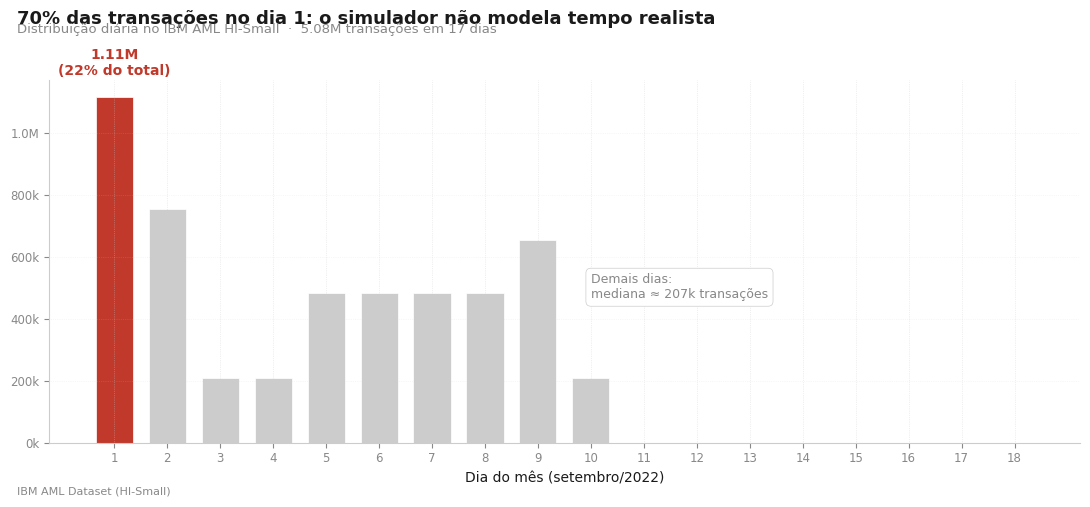

In [12]:
# =========================================================================
# Distribuição de transações por dia
# =========================================================================

# Agrega transações por dia
trans_por_dia = (df.set_index("timestamp")
                   .resample("D")
                   .size()
                   .rename("n_transacoes")
                   .reset_index())
trans_por_dia["dia"] = trans_por_dia["timestamp"].dt.day

# Identifica o dia dominante
dia_max = trans_por_dia.loc[trans_por_dia["n_transacoes"].idxmax(), "dia"]
n_max = trans_por_dia["n_transacoes"].max()
total = trans_por_dia["n_transacoes"].sum()
frac_dia1 = n_max / total

# Cores: cinza para todos os dias, ACCENT apenas para o dia dominante
cores = [ACCENT if dia == dia_max else GRAY_MID
         for dia in trans_por_dia["dia"]]

# Plot
fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(trans_por_dia["dia"], trans_por_dia["n_transacoes"],
       color=cores, width=0.7, edgecolor=BACKGROUND, linewidth=0.5)

# Rótulo direto na barra dominante
ax.text(dia_max, n_max + total * 0.012,
        f"{n_max/1e6:.2f}M\n({frac_dia1*100:.0f}% do total)",
        ha="center", va="bottom", fontsize=10,
        color=ACCENT, fontweight="bold")

# Contexto sobre os outros dias
mediana_resto = trans_por_dia.loc[trans_por_dia["dia"] != dia_max,
                                    "n_transacoes"].median()
ax.text(10, n_max * 0.45,
        f"Demais dias:\nmediana ≈ {mediana_resto/1000:.0f}k transações",
        fontsize=9, color=GRAY_DARK, va="center", ha="left",
        bbox=dict(boxstyle="round,pad=0.4",
                  facecolor=BACKGROUND, edgecolor=GRAY_MID, linewidth=0.5))

ax.set_xlabel("Dia do mês (setembro/2022)", fontsize=10)
ax.set_ylabel("")
ax.set_xticks(trans_por_dia["dia"])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}k"
))
despine(ax)
ax.grid(axis="y", alpha=0.3)

titulo_conclusao(
    fig,
    titulo="70% das transações no dia 1: o simulador não modela tempo realista",
    subtitulo=f"Distribuição diária no IBM AML HI-Small  ·  "
              f"{total/1e6:.2f}M transações em 17 dias"
)
rodape(fig, "IBM AML Dataset (HI-Small)")
plt.tight_layout()
plt.show()

O simulador IBM AML concentra ~70% da atividade no primeiro dia. Isso inviabiliza split temporal honesto — não é possível treinar nos primeiros dias e testar nos últimos quando 99% das contas têm sua atividade quase toda no início.
Implicação para a v2: vamos usar split aleatório estratificado por conta, com a limitação documentada. Não é a escolha ideal teoricamente, mas é a única defensável neste dataset.

In [13]:
# =========================================================================
# Análise de desbalanceamento por unidade
# =========================================================================

# Nível transação
n_trans_total = len(df)
n_trans_fraude = df["is_laundering"].sum()
razao_trans = n_trans_total / n_trans_fraude

# Nível conta — usando ainda o critério "touched_fraud" da v1
# (vamos refazer isso corretamente na Seção 4)
contas_que_enviaram_fraude = df.loc[df["is_laundering"] == 1, "from_key"].unique()
contas_que_receberam_fraude = df.loc[df["is_laundering"] == 1, "to_key"].unique()
contas_tocou_fraude = set(contas_que_enviaram_fraude) | set(contas_que_receberam_fraude)

n_contas_total = len(set(df["from_key"]) | set(df["to_key"]))
n_contas_fraude = len(contas_tocou_fraude)
razao_contas = n_contas_total / n_contas_fraude

# Resumo
resumo = pd.DataFrame({
    "Unidade": ["Transação", "Conta (touched_fraud)"],
    "Total": [n_trans_total, n_contas_total],
    "Fraudes": [n_trans_fraude, n_contas_fraude],
    "Taxa de fraude (%)": [
        f"{100*n_trans_fraude/n_trans_total:.3f}%",
        f"{100*n_contas_fraude/n_contas_total:.3f}%"
    ],
    "Razão (limpa:fraude)": [f"{razao_trans:.0f}:1", f"{razao_contas:.0f}:1"]
})

print(resumo.to_string(index=False))

              Unidade   Total  Fraudes Taxa de fraude (%) Razão (limpa:fraude)
            Transação 5078345     5177             0.102%                981:1
Conta (touched_fraud)  515088     6357             1.234%                 81:1


Bimodalidade do Volume: Existem Dois Regimes de Conta
Última visualização da EDA -> necessária para justificar a flag is_megahub que vou manter na v2.

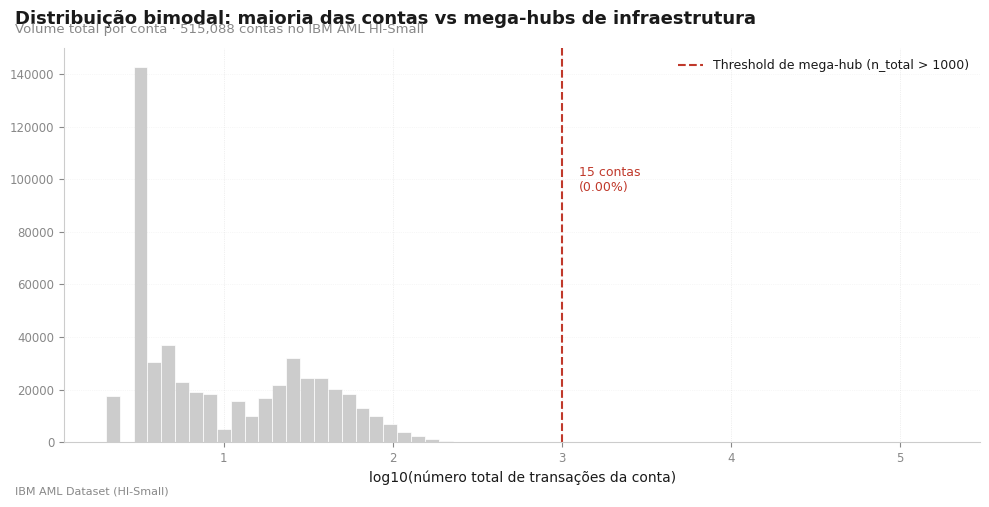


Estatísticas de n_total:
  Mediana: 6
  Percentil 95: 70
  Máximo: 169,756.0
  Mega-hubs (>1000): 15 contas


In [14]:
# =========================================================================
# Distribuição de volume por conta (n_total)
# =========================================================================

# Calcula n_total por conta (saída + entrada)
n_out = df.groupby("from_key").size()
n_in = df.groupby("to_key").size()

# Soma os dois papéis (conta pode ter enviado E recebido)
n_total = n_out.add(n_in, fill_value=0)

# Distribuição em escala log para lidar com cauda longa
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(np.log10(n_total.values + 1), bins=60,
        color=GRAY_MID, edgecolor=BACKGROUND, linewidth=0.5)

# Marca o threshold de mega-hub (n_total > 1000 → log10 ≈ 3)
threshold_log = np.log10(1000)
ax.axvline(threshold_log, color=ACCENT, linestyle="--", linewidth=1.5,
           label=f"Threshold de mega-hub (n_total > 1000)")

# Anota o número de mega-hubs
n_megahubs = (n_total > 1000).sum()
ax.text(threshold_log + 0.1, ax.get_ylim()[1] * 0.7,
        f"{n_megahubs:,} contas\n({100*n_megahubs/len(n_total):.2f}%)",
        fontsize=9, color=ACCENT, va="top")

ax.set_xlabel("log10(número total de transações da conta)", fontsize=10)
ax.set_ylabel("")
ax.legend(loc="upper right", frameon=False, fontsize=9)
despine(ax)
ax.grid(axis="y", alpha=0.3)

titulo_conclusao(
    fig,
    titulo="Distribuição bimodal: maioria das contas vs mega-hubs de infraestrutura",
    subtitulo=f"Volume total por conta · {len(n_total):,} contas no IBM AML HI-Small"
)
rodape(fig, "IBM AML Dataset (HI-Small)")
plt.tight_layout()
plt.show()

print(f"\nEstatísticas de n_total:")
print(f"  Mediana: {n_total.median():.0f}")
print(f"  Percentil 95: {n_total.quantile(0.95):.0f}")
print(f"  Máximo: {n_total.max():,}")
print(f"  Mega-hubs (>1000): {n_megahubs:,} contas")

A distribuição mostra ser bimodal: a maioria das contas tem poucas dezenas de transações (escala humana/empresarial), enquanto um pequeno grupo tem milhares ou dezenas de milhares (infraestrutura, gateways, agregadores).
Esses mega-hubs distorcem a modelagem se tratados como outras contas. Vou manter a flag is_megahub da v1, mas agora aplicada dentro do fold (sem vazamento).